## **Swin Transformer for Brain Tumor Classification**
Brain Tumor Sub-Region Classification – BraTS2020

Task: Patient-level multi-label binary classification → [NCR, ED, ET]

Input: 155 MRI slices × 4 channels (T1, T1ce, T2, FLAIR) per patient

**1. Import Libraries**

In [ ]:
!pip install timm h5py scikit-learn --quiet

import torch

print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')

if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch: 2.10.0+cu128
CUDA: True
GPU: NVIDIA A100-SXM4-80GB


**2. Google Drive Mounting**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**3. Download BraTS 2020 Dataset From Kaggle**

In [ ]:
from google.colab import files

files.upload()  # upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d awsaf49/brats2020-training-data -p /content/brats2020 --unzip

print('Download complete!')

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/awsaf49/brats2020-training-data
License(s): CC0-1.0
100% 6.76G/6.76G [06:29<00:00, 18.6MB/s]

Download complete!


**4. Dataset Directory Verification**

In [ ]:
import os

DATA_ROOT = '/content/brats2020'

for root, dirs, flist in os.walk(DATA_ROOT):
    level = root.replace(DATA_ROOT, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')

    if level < 2:
        sub = '  ' * (level + 1)
        for f in flist[:5]:
            print(f'{sub}{f}')

brats2020/
  BraTS20 Training Metadata.csv
  BraTS2020_training_data/
    content/
      data/


**5. Import Required Packages**

In [ ]:
import os, random, time, glob, warnings, re
import numpy as np
import pandas as pd
import h5py

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms.functional as TF
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, f1_score, precision_score,
    recall_score, accuracy_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve,
    average_precision_score
)

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


**6. Configuration and Hyperparameters**

In [ ]:
CFG = {
    'data_root':       '/content/brats2020',
    'csv_path':        '/content/brats2020/BraTS20 Training Metadata.csv',
    'h5_dir':          '/content/brats2020',

    'img_size':        224,
    'num_slices':      155,
    'num_channels':    4,
    'num_classes':     3,

    'backbone':        'swin_tiny_patch4_window7_224',
    'embed_dim':       768,

    'tt_num_heads':    8,
    'tt_num_layers':   2,
    'tt_ff_mult':      4,

    'epochs':          30,
    'batch_size':      4,

    'lr_backbone':     1e-5,
    'lr_head':         1e-4,

    'weight_decay':    1e-4,
    'dropout':         0.3,
    'patience':        7,

    'train_frac':      0.70,
    'val_frac':        0.15,
    'test_frac':       0.15,

    'num_workers':     4,
    'pin_memory':      True,
    'mixed_precision': True,

    'checkpoint_path': '/content/swin_temporal_best.pth',
}

CLASS_NAMES = ['NCR', 'ED', 'ET']

print('Config ready.')

Config ready.


**7. Load Metadata CSV**

In [ ]:
df = pd.read_csv(CFG['csv_path'])

print(f'CSV shape: {df.shape}')
print(df.head())
print('Columns:', df.columns.tolist())

CSV shape: (57195, 8)
                                          slice_path  target  volume  slice  \
0  ../input/brats2020-training-data/BraTS2020_tra...       0      41      0   
1  ../input/brats2020-training-data/BraTS2020_tra...       0      41      1   
2  ../input/brats2020-training-data/BraTS2020_tra...       0      41      2   
3  ../input/brats2020-training-data/BraTS2020_tra...       0      41      3   
4  ../input/brats2020-training-data/BraTS2020_tra...       0      41      4   

   label0_pxl_cnt  label1_pxl_cnt  label2_pxl_cnt  background_ratio  
0               0               0               0               1.0  
1               0               0               0               1.0  
2               0               0               0               1.0  
3               0               0               0               1.0  
4               0               0               0               1.0  
Columns: ['slice_path', 'target', 'volume', 'slice', 'label0_pxl_cnt', 'label1_pxl_

**8. Patient-Level Label Creation**

In [ ]:
ID_COL  = 'volume'

ET_COL  = 'label2_pxl_cnt'
NCR_COL = 'label0_pxl_cnt'
ED_COL  = 'label1_pxl_cnt'

for col in [ET_COL, NCR_COL, ED_COL]:
    assert col in df.columns, f'{col} not found'

patient_df = df.groupby(ID_COL).agg(
    et_total   = (ET_COL,  'sum'),
    ncr_total  = (NCR_COL, 'sum'),
    ed_total   = (ED_COL,  'sum'),
).reset_index()

patient_df['NCR'] = (patient_df['ncr_total'] > 0).astype(int)
patient_df['ED']  = (patient_df['ed_total']  > 0).astype(int)
patient_df['ET']  = (patient_df['et_total']  > 0).astype(int)

patient_df = patient_df[[ID_COL, 'NCR', 'ED', 'ET']]
patient_df = patient_df.rename(columns={ID_COL: 'patient_id'})

print(patient_df.head())
print(patient_df[['NCR', 'ED', 'ET']].sum())

   patient_id  NCR  ED  ET
0           1    1   1   1
1           2    1   1   1
2           3    1   1   1
3           4    1   1   1
4           5    1   1   1
NCR    368
ED     368
ET     342
dtype: int64


**9. H5 File Mapping**

In [ ]:
h5_files = glob.glob(os.path.join(CFG['h5_dir'], '**', '*.h5'), recursive=True)

print(f'Found {len(h5_files)} h5 files')

h5_map = {}

for fpath in h5_files:
    m = re.match(r'volume_(\d+)_slice_(\d+)\.h5', os.path.basename(fpath))
    if m:
        vid = int(m.group(1))
        h5_map.setdefault(vid, []).append(fpath)

for vid in h5_map:
    h5_map[vid].sort(key=lambda p: int(re.search(r'slice_(\d+)', p).group(1)))

patient_df['patient_id'] = patient_df['patient_id'].astype(int)
h5_map = {int(k): v for k, v in h5_map.items()}

patient_df = patient_df[patient_df['patient_id'].isin(h5_map)].reset_index(drop=True)
patient_df['h5_paths'] = patient_df['patient_id'].map(h5_map)

print(f'Matched patients: {len(patient_df)}')
print(patient_df['h5_paths'].apply(len).head())

Found 57195 h5 files
Matched patients: 369
0    155
1    155
2    155
3    155
4    155
Name: h5_paths, dtype: int64


**10. Train Validation Test Split**

In [ ]:
train_val_df, test_df = train_test_split(
    patient_df,
    test_size=CFG['test_frac'],
    random_state=SEED,
    shuffle=True
)

val_size = CFG['val_frac'] / (CFG['train_frac'] + CFG['val_frac'])

train_df, val_df = train_test_split(
    train_val_df,
    test_size=val_size,
    random_state=SEED,
    shuffle=True
)

print(f'Train: {len(train_df)}')
print(f'Val: {len(val_df)}')
print(f'Test: {len(test_df)}')

Train: 257
Val: 56
Test: 56


**11. Custom Dataset Class**

In [ ]:
class BraTS2020Dataset(Dataset):
    def __init__(self, df, img_size=224, num_slices=155, augment=False):
        self.df = df.reset_index(drop=True)
        self.img_size = img_size
        self.num_slices = num_slices
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def _load_slice(self, path):
        with h5py.File(path, 'r') as f:
            img = f['image'][()]

        img = img.transpose(2, 0, 1).astype(np.float32)

        for c in range(img.shape[0]):
            mn, mx = img[c].min(), img[c].max()
            if mx > mn:
                img[c] = (img[c] - mn) / (mx - mn)

        t = torch.from_numpy(img)

        t = F.interpolate(
            t.unsqueeze(0),
            size=(self.img_size, self.img_size),
            mode='bilinear',
            align_corners=False
        ).squeeze(0)

        return t

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        label = torch.tensor(
            [row['NCR'], row['ED'], row['ET']],
            dtype=torch.float32
        )

        paths = row['h5_paths']

        slices = []

        for i in range(self.num_slices):
            sl = self._load_slice(paths[i])

            if self.augment:
                if random.random() > 0.5:
                    sl = TF.hflip(sl)
                if random.random() > 0.5:
                    sl = TF.vflip(sl)

            slices.append(sl)

        return torch.stack(slices, dim=0), label


ds_tmp = BraTS2020Dataset(patient_df.head(1))
vol, lbl = ds_tmp[0]

print(f'Volume shape: {vol.shape}')
print(f'Label: {lbl}')
print(f'Value range: [{vol.min():.3f}, {vol.max():.3f}]')

Volume shape: torch.Size([155, 4, 224, 224])
Label: tensor([1., 1., 1.])
Value range: [0.000, 1.000]


**12. DataLoader Creation**

In [ ]:
train_dataset = BraTS2020Dataset(train_df, augment=True)
val_dataset   = BraTS2020Dataset(val_df, augment=False)
test_dataset  = BraTS2020Dataset(test_df, augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG['batch_size'],
    shuffle=True,
    num_workers=CFG['num_workers'],
    pin_memory=CFG['pin_memory']
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG['batch_size'],
    shuffle=False,
    num_workers=CFG['num_workers'],
    pin_memory=CFG['pin_memory']
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CFG['batch_size'],
    shuffle=False,
    num_workers=CFG['num_workers'],
    pin_memory=CFG['pin_memory']
)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches: {len(val_loader)}')
print(f'Test batches: {len(test_loader)}')

Train batches: 65
Val batches: 14
Test batches: 14


**13. Temporal Transformer Pooling Module**

In [ ]:
class TemporalTransformerPooling(nn.Module):
    def __init__(
        self,
        embed_dim=768,
        num_slices=155,
        num_heads=8,
        num_layers=2,
        ff_mult=4,
        dropout=0.3
    ):
        super().__init__()

        self.pos_embed = nn.Parameter(
            torch.randn(1, num_slices, embed_dim) * 0.02
        )

        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * ff_mult,
            dropout=dropout,
            activation='gelu',
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            layer,
            num_layers=num_layers
        )

    def forward(self, H):
        H = H + self.pos_embed[:, :H.size(1)]
        H = self.encoder(H)
        z = H.mean(dim=1)

        return z, None

**14.Swin-T with Temporal Transformer Classifier**

In [ ]:
class SwinTemporalClassifier(nn.Module):
    def __init__(
        self,
        embed_dim=768,
        num_slices=155,
        num_heads=8,
        num_layers=2,
        num_classes=3,
        dropout=0.3
    ):
        super().__init__()

        backbone = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=True,
            num_classes=0,
            global_pool='avg'
        )

        old = backbone.patch_embed.proj

        new = nn.Conv2d(
            4,
            old.out_channels,
            old.kernel_size,
            old.stride,
            old.padding,
            bias=(old.bias is not None)
        )

        with torch.no_grad():
            new.weight[:, :3] = old.weight
            new.weight[:, 3:] = old.weight.mean(dim=1, keepdim=True)

            if old.bias is not None:
                new.bias.copy_(old.bias)

        backbone.patch_embed.proj = new

        self.backbone = backbone

        self.temporal = TemporalTransformerPooling(
            embed_dim=embed_dim,
            num_slices=num_slices,
            num_heads=num_heads,
            num_layers=num_layers,
            dropout=dropout
        )

        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 128),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        B, S, C, H, W = x.shape

        h = self.backbone(x.view(B * S, C, H, W))

        H_seq = h.view(B, S, -1)

        z, attn_w = self.temporal(H_seq)

        logits = self.head(z)

        return logits, attn_w

**15 Model Initialization and Parameter Summary**

In [ ]:
model = SwinTemporalClassifier(
    embed_dim=CFG['embed_dim'],
    num_slices=CFG['num_slices'],
    num_heads=CFG['tt_num_heads'],
    num_layers=CFG['tt_num_layers'],
    num_classes=CFG['num_classes'],
    dropout=CFG['dropout']
).to(DEVICE)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total params: {total:,}')
print(f'Trainable params: {trainable:,}')

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Total params: 41,916,029
Trainable params: 41,916,029


**16 Dummy Forward Pass Verification**

In [ ]:
with torch.no_grad():
    dummy = torch.randn(2, 10, 4, 224, 224).to(DEVICE)
    lg, aw = model(dummy)

print(f'Logits shape: {lg.shape}')
print(f'Attention: {aw}')

Logits shape: torch.Size([2, 3])
Attention: None


**17 Class Imbalance Handling and Loss Function**

In [ ]:
n = len(train_df)

pos_weights = torch.tensor([
    (n - train_df['NCR'].sum()) / (train_df['NCR'].sum() + 1e-6),
    (n - train_df['ED'].sum())  / (train_df['ED'].sum()  + 1e-6),
    (n - train_df['ET'].sum())  / (train_df['ET'].sum()  + 1e-6),
], dtype=torch.float32).to(DEVICE)

print(f'pos_weights: {pos_weights.cpu().tolist()}')

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

pos_weights: [0.00390625, 0.00390625, 0.08438818901777267]


**18 Optimizer, Learning Rate Scheduler, and Mixed Precision Setup**

In [ ]:
optimizer = torch.optim.AdamW([
    {
        'params': model.backbone.parameters(),
        'lr': CFG['lr_backbone']
    },
    {
        'params': list(model.temporal.parameters()) + list(model.head.parameters()),
        'lr': CFG['lr_head']
    }
], weight_decay=CFG['weight_decay'])

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CFG['epochs'],
    eta_min=1e-7
)

scaler = torch.cuda.amp.GradScaler(
    enabled=CFG['mixed_precision']
)

print('Loss, optimizer and scheduler ready.')

Loss, optimizer and scheduler ready.


**19 Training Function for One Epoch**

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for i, (vols, labels) in enumerate(loader):
        vols = vols.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=CFG['mixed_precision']):
            logits, _ = model(vols)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        preds = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy()

        all_preds.append(preds)
        all_labels.append(labels.int().cpu().numpy())

        if (i + 1) % 10 == 0:
            print(f'Batch [{i+1}/{len(loader)}] loss={loss.item():.4f}')

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average='macro',
        zero_division=0
    )

    return total_loss / len(loader), macro_f1

**20 Evaluation Function**

In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    for vols, labels in loader:
        vols = vols.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=CFG['mixed_precision']):
            logits, _ = model(vols)
            loss = criterion(logits, labels)

        total_loss += loss.item()

        probs = torch.sigmoid(logits).float().cpu().numpy()
        preds = (probs >= 0.5).astype(int)

        all_preds.append(preds)
        all_probs.append(probs)
        all_labels.append(labels.int().cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average='macro',
        zero_division=0
    )

    return total_loss / len(loader), macro_f1, all_preds, all_labels, all_probs

**21 Model Training with Early Stopping and Checkpoint Saving**

In [ ]:
history = {
    'train_loss': [],
    'val_loss': [],
    'train_f1': [],
    'val_f1': []
}

best_val_f1 = -1.0
patience_counter = 0

for epoch in range(1, CFG['epochs'] + 1):
    print(f'\nEpoch {epoch}/{CFG["epochs"]}')

    tr_loss, tr_f1 = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        scaler,
        DEVICE
    )

    vl_loss, vl_f1, _, _, _ = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    scheduler.step()

    print(f'Train Loss: {tr_loss:.4f} | Train F1: {tr_f1:.4f}')
    print(f'Val Loss:   {vl_loss:.4f} | Val F1:   {vl_f1:.4f}')

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_f1'].append(tr_f1)
    history['val_f1'].append(vl_f1)

    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        patience_counter = 0

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1': best_val_f1
        }, CFG['checkpoint_path'])

        print(f'Best model saved. Val F1 = {best_val_f1:.4f}')

    else:
        patience_counter += 1
        print(f'No improvement: {patience_counter}/{CFG["patience"]}')

        if patience_counter >= CFG['patience']:
            print('Early stopping')
            break

print(f'Best Val F1: {best_val_f1:.4f}')


Epoch 1/30
Batch [10/65] loss=0.0265
Batch [20/65] loss=0.0133
Batch [30/65] loss=0.0686
Batch [40/65] loss=0.0225
Batch [50/65] loss=0.0186
Batch [60/65] loss=0.1022
Train Loss: 0.0459 | Train F1: 0.8740
Val Loss:   0.0355 | Val F1:   0.9877
Best model saved. Val F1 = 0.9877

Epoch 2/30
Batch [10/65] loss=0.0573
Batch [20/65] loss=0.0273
Batch [30/65] loss=0.0758
Batch [40/65] loss=0.0206
Batch [50/65] loss=0.2053
Batch [60/65] loss=0.0399
Train Loss: 0.0440 | Train F1: 0.7852
Val Loss:   0.0390 | Val F1:   0.3210
No improvement: 1/7

Epoch 3/30
Batch [10/65] loss=0.0083
Batch [20/65] loss=0.0298
Batch [30/65] loss=0.0131
Batch [40/65] loss=0.1227
Batch [50/65] loss=0.0283
Batch [60/65] loss=0.0552
Train Loss: 0.0479 | Train F1: 0.6598
Val Loss:   0.0368 | Val F1:   0.3333
No improvement: 2/7

Epoch 4/30
Batch [10/65] loss=0.0611
Batch [20/65] loss=0.0617
Batch [30/65] loss=0.0307
Batch [40/65] loss=0.0200
Batch [50/65] loss=0.0918
Batch [60/65] loss=0.0137
Train Loss: 0.0405 | Train

**22 Best Model Loading and Test Set Evaluation**

In [ ]:
ckpt = torch.load(CFG['checkpoint_path'], map_location=DEVICE)

model.load_state_dict(ckpt['model_state_dict'])

print(f'Loaded best model from epoch {ckpt["epoch"]}')
print(f'Best validation F1: {ckpt["val_f1"]:.4f}')

test_loss, test_f1, test_preds, test_labels, test_probs = evaluate(
    model,
    test_loader,
    criterion,
    DEVICE
)

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Macro F1: {test_f1:.4f}')

print(
    classification_report(
        test_labels,
        test_preds,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

Loaded best model from epoch 1
Best validation F1: 0.9877
Test Loss: 0.0315
Test Macro F1: 0.9908
              precision    recall  f1-score   support

         NCR     1.0000    1.0000    1.0000        56
          ED     1.0000    1.0000    1.0000        56
          ET     0.9464    1.0000    0.9725        53

   micro avg     0.9821    1.0000    0.9910       165
   macro avg     0.9821    1.0000    0.9908       165
weighted avg     0.9828    1.0000    0.9912       165
 samples avg     0.9821    1.0000    0.9893       165



**23 Training Curves and Evaluation Visualization**

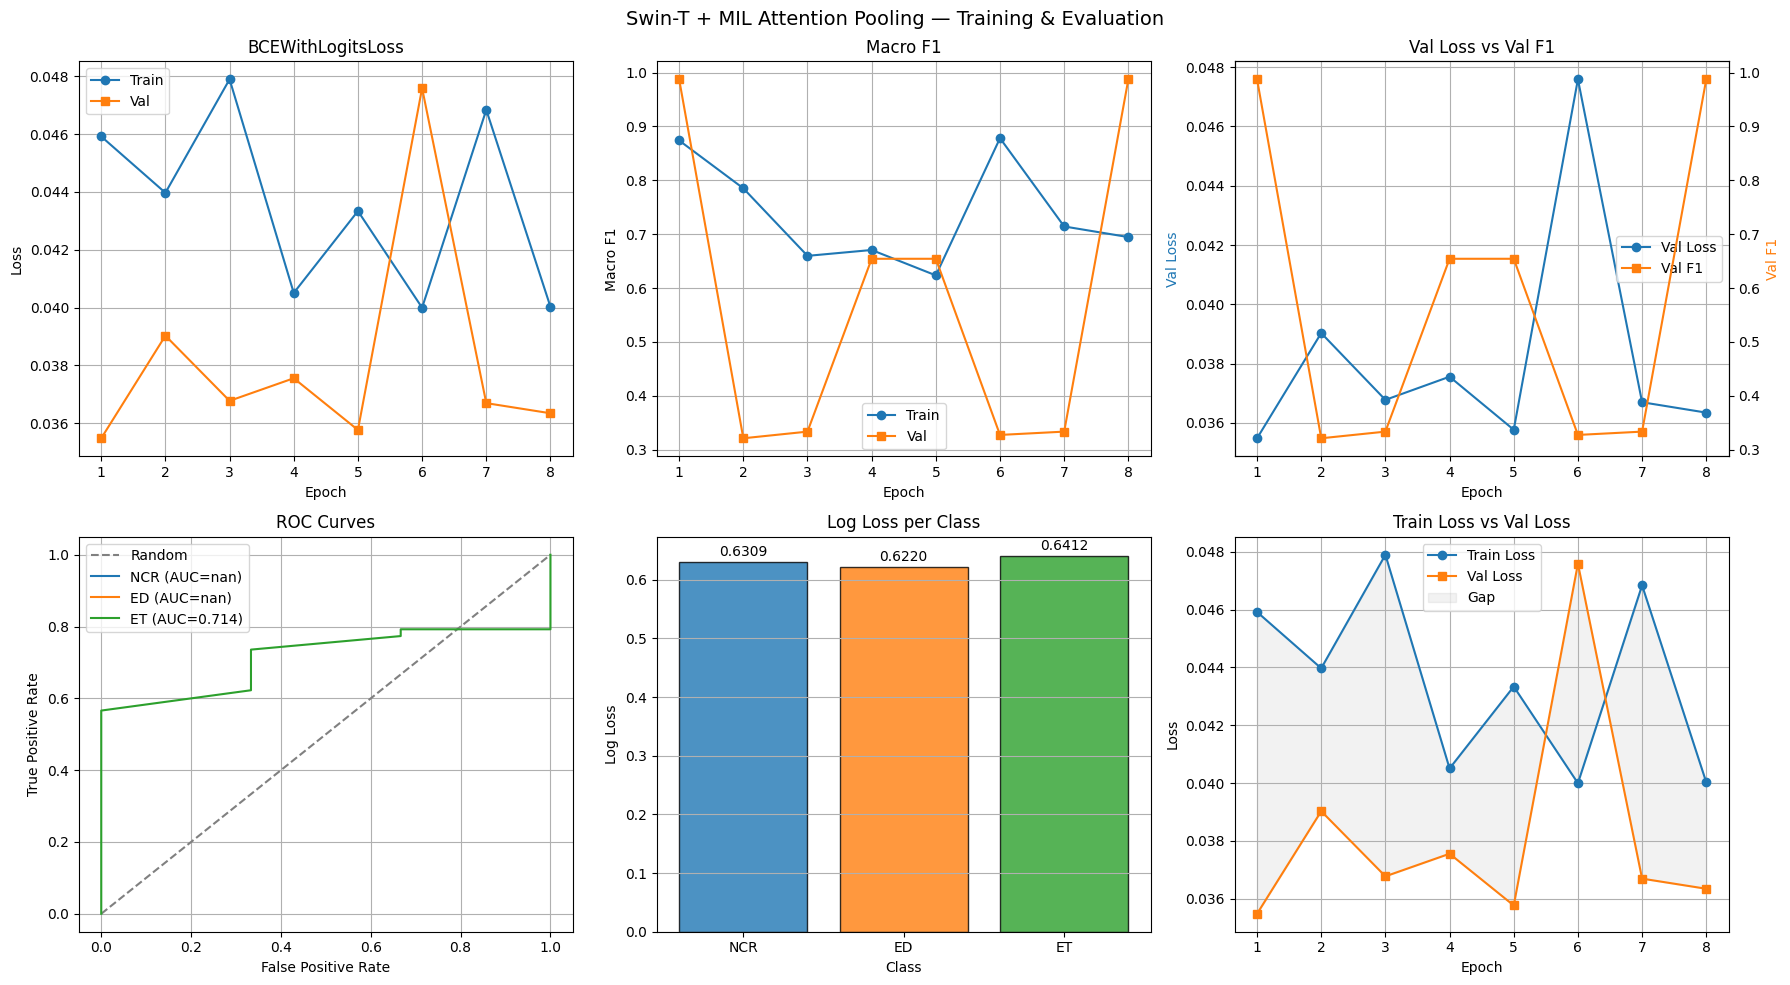

In [ ]:
epochs_ran = len(history['train_loss'])
epochs = range(1, epochs_ran + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Loss Curve
axes[0,0].plot(epochs, history['train_loss'], 'o-', label='Train')
axes[0,0].plot(epochs, history['val_loss'],   's-', label='Val')
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Loss')
axes[0,0].set_title('BCEWithLogitsLoss'); axes[0,0].legend(); axes[0,0].grid(True)

# F1 Curve
axes[0,1].plot(epochs, history['train_f1'], 'o-', label='Train')
axes[0,1].plot(epochs, history['val_f1'],   's-', label='Val')
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Macro F1')
axes[0,1].set_title('Macro F1'); axes[0,1].legend(); axes[0,1].grid(True)

# Val Loss vs Val F1 (dual axis)
ax3 = axes[0,2]
ax3b = ax3.twinx()
ax3.plot(epochs, history['val_loss'], 'o-', color='tab:blue', label='Val Loss')
ax3b.plot(epochs, history['val_f1'],  's-', color='tab:orange', label='Val F1')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Val Loss', color='tab:blue')
ax3b.set_ylabel('Val F1', color='tab:orange')
ax3.set_title('Val Loss vs Val F1')
ax3.grid(True)
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='center right')

# Collect test probs
model.eval()
all_probs_raw, all_labels_raw = [], []
with torch.no_grad():
    for vols, labels in test_loader:
        vols = vols.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=CFG['mixed_precision']):
            logits, _ = model(vols)
        probs = torch.sigmoid(logits).cpu().numpy()
        for p, l in zip(probs, labels.numpy()):
            all_probs_raw.append(p.tolist())
            all_labels_raw.append(l.tolist())

all_probs_np  = np.array(all_probs_raw)
all_labels_np = np.array(all_labels_raw)
CLASS_NAMES   = ['NCR', 'ED', 'ET']
COLORS        = ['tab:blue', 'tab:orange', 'tab:green']

from sklearn.metrics import roc_curve, roc_auc_score, log_loss

# ROC Curves
axes[1,0].plot([0,1], [0,1], '--', color='gray', label='Random')
for i, (cls, col) in enumerate(zip(CLASS_NAMES, COLORS)):
    try:
        fpr, tpr, _ = roc_curve(all_labels_np[:, i], all_probs_np[:, i])
        auc = roc_auc_score(all_labels_np[:, i], all_probs_np[:, i])
        axes[1,0].plot(fpr, tpr, color=col, label=f'{cls} (AUC={auc:.3f})')
    except ValueError:
        axes[1,0].text(0.3, 0.5 - i*0.1, f'{cls}: N/A (1 class)', color=col)
axes[1,0].set_xlabel('False Positive Rate')
axes[1,0].set_ylabel('True Positive Rate')
axes[1,0].set_title('ROC Curves')
axes[1,0].legend(); axes[1,0].grid(True)

# Log Loss per class
logloss_vals = []
for i, cls in enumerate(CLASS_NAMES):
    try:
        ll = log_loss(all_labels_np[:, i], all_probs_np[:, i], labels=[0,1])
    except Exception:
        ll = 0
    logloss_vals.append(ll)

bars = axes[1,1].bar(CLASS_NAMES, logloss_vals, color=COLORS, alpha=0.8, edgecolor='black')
axes[1,1].set_xlabel('Class'); axes[1,1].set_ylabel('Log Loss')
axes[1,1].set_title('Log Loss per Class')
axes[1,1].grid(True, axis='y')
for bar, val in zip(bars, logloss_vals):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                   f'{val:.4f}', ha='center', va='bottom', fontsize=10)

# Train Loss vs Val Loss (overlaid, same axis)
axes[1,2].plot(epochs, history['train_loss'], 'o-', color='tab:blue', label='Train Loss')
axes[1,2].plot(epochs, history['val_loss'],   's-', color='tab:orange', label='Val Loss')
axes[1,2].fill_between(epochs, history['train_loss'], history['val_loss'],
                        alpha=0.1, color='gray', label='Gap')
axes[1,2].set_xlabel('Epoch'); axes[1,2].set_ylabel('Loss')
axes[1,2].set_title('Train Loss vs Val Loss')
axes[1,2].legend(); axes[1,2].grid(True)

plt.suptitle('Swin-T + MIL Attention Pooling — Training & Evaluation', fontsize=14)
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

**24 Class-Wise Confusion Matrix Visualization**

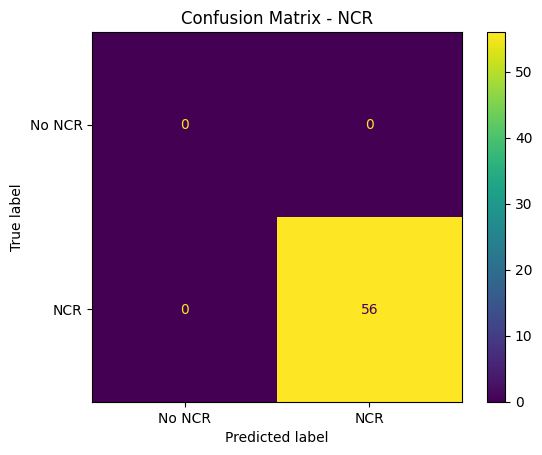

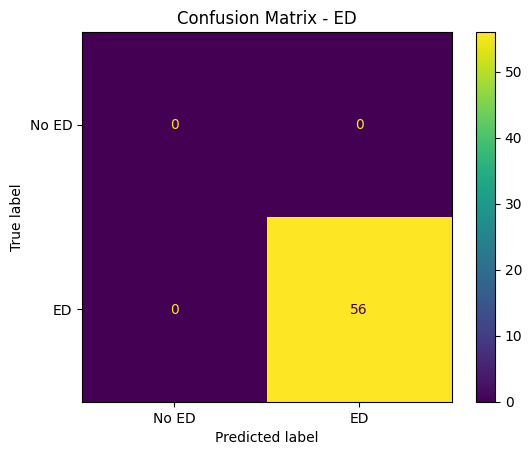

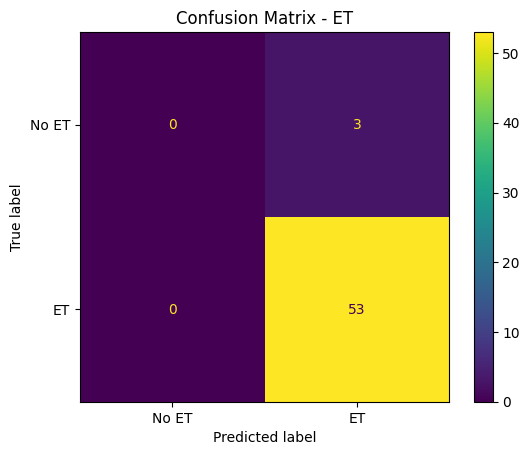

In [ ]:
for i, cls in enumerate(CLASS_NAMES):
    cm = confusion_matrix(
        test_labels[:, i],
        test_preds[:, i],
        labels=[0, 1]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[f'No {cls}', cls]
    )

    disp.plot()
    plt.title(f'Confusion Matrix - {cls}')
    plt.show()

**25 Class-Wise Precision-Recall Curve Analysis**

NCR: PR not available
ED: PR not available


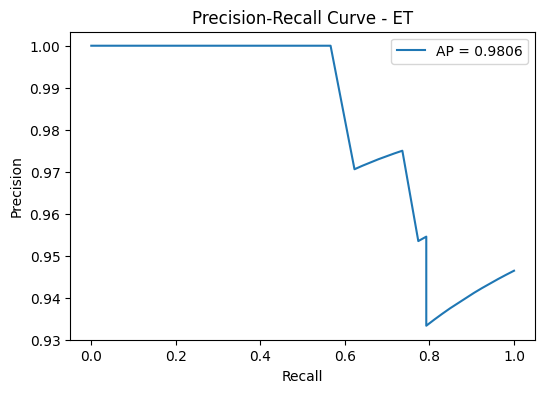

In [ ]:
for i, cls in enumerate(CLASS_NAMES):
    if len(np.unique(test_labels[:, i])) < 2:
        print(f'{cls}: PR not available')
        continue

    p, r, _ = precision_recall_curve(test_labels[:, i], test_probs[:, i])
    ap = average_precision_score(test_labels[:, i], test_probs[:, i])

    plt.figure(figsize=(6, 4))
    plt.plot(r, p, label=f'AP = {ap:.4f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - {cls}')
    plt.legend()
    plt.show()

**26 Patient-Level Prediction Visualization**

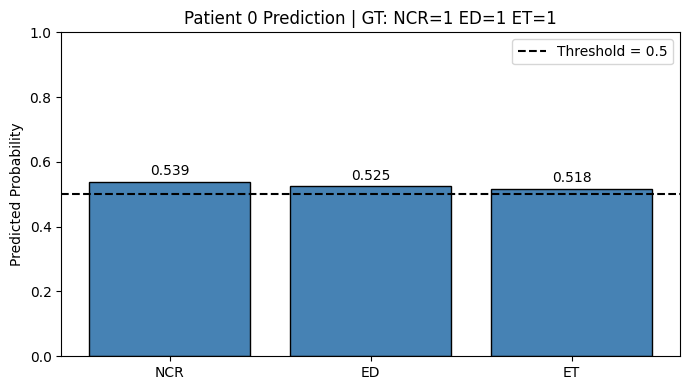

In [ ]:
@torch.no_grad()
def visualize_patient_prediction(model, dataset, idx, device):
    model.eval()

    vol, gt = dataset[idx]
    vol = vol.unsqueeze(0).to(device)

    with torch.cuda.amp.autocast(enabled=CFG['mixed_precision']):
        logits, _ = model(vol)

    probs = torch.sigmoid(logits).squeeze().float().cpu().numpy()
    gt = gt.numpy()

    plt.figure(figsize=(7, 4))

    colors = ['steelblue' if p >= 0.5 else 'salmon' for p in probs]

    bars = plt.bar(
        CLASS_NAMES,
        probs,
        color=colors,
        edgecolor='black'
    )

    plt.axhline(0.5, color='black', linestyle='--', label='Threshold = 0.5')
    plt.ylim(0, 1)
    plt.ylabel('Predicted Probability')

    plt.title(
        f'Patient {idx} Prediction | '
        f'GT: NCR={int(gt[0])} ED={int(gt[1])} ET={int(gt[2])}'
    )

    for b, p in zip(bars, probs):
        plt.text(
            b.get_x() + b.get_width() / 2,
            p + 0.02,
            f'{p:.3f}',
            ha='center'
        )

    plt.legend()
    plt.tight_layout()
    plt.savefig(f'/content/patient_{idx}_temporal.png', dpi=150)
    plt.show()


visualize_patient_prediction(model, test_dataset, 0, DEVICE)

**27 Final Test Metrics and Performance Summary**

In [ ]:
results = {}

for i, lbl in enumerate(CLASS_NAMES):
    results[lbl] = {
        'precision': precision_score(test_labels[:, i], test_preds[:, i], zero_division=0),
        'recall':    recall_score(test_labels[:, i],    test_preds[:, i], zero_division=0),
        'f1':        f1_score(test_labels[:, i],        test_preds[:, i], zero_division=0),
        'accuracy':  accuracy_score(test_labels[:, i],  test_preds[:, i])
    }
    if len(np.unique(test_labels[:, i])) >= 2:
        results[lbl]['auroc'] = roc_auc_score(test_labels[:, i], test_probs[:, i])
    else:
        results[lbl]['auroc'] = float('nan')

results_df = pd.DataFrame(results).T
results_df.index.name = 'Label'
print(results_df.round(4))
results_df.to_csv('/content/test_results_temporal.csv')
=
overall_acc     = accuracy_score(test_labels.flatten(), test_preds.flatten())
macro_precision = float(precision_score(test_labels, test_preds, average='macro', zero_division=0))
macro_recall    = float(recall_score(test_labels,    test_preds, average='macro', zero_division=0))
macro_f1        = float(f1_score(test_labels,        test_preds, average='macro', zero_division=0))
macro_auroc     = float(np.nanmean([results[lbl]['auroc'] for lbl in CLASS_NAMES]))
mean_logloss    = float(np.nanmean([
    log_loss(test_labels[:, i], test_probs[:, i], labels=[0,1])
    if len(np.unique(test_labels[:, i])) >= 2 else float('nan')
    for i in range(len(CLASS_NAMES))
]))

print('\nFINAL SUMMARY:')
print(f'  Accuracy:        {overall_acc:.4f}')
print(f'  Macro Precision: {macro_precision:.4f}')
print(f'  Macro Recall:    {macro_recall:.4f}')
print(f'  Macro F1:        {macro_f1:.4f}')
print(f'  Macro AUROC:     {macro_auroc:.4f}')
print(f'  Mean LogLoss:    {mean_logloss:.4f}')

       precision  recall      f1  accuracy   auroc
Label                                             
NCR       1.0000     1.0  1.0000    1.0000     NaN
ED        1.0000     1.0  1.0000    1.0000     NaN
ET        0.9464     1.0  0.9725    0.9464  0.7138

FINAL SUMMARY:
  Accuracy:        0.9821
  Macro Precision: 0.9821
  Macro Recall:    1.0000
  Macro F1:        0.9908
  Macro AUROC:     0.7138
  Mean LogLoss:    0.6412


**28 Exact Match Accuracy**

In [ ]:
exact_match_accuracy = (test_preds == test_labels).all(axis=1).mean()
print(f"Exact Match Accuracy: {exact_match_accuracy * 100:.2f}%")

Exact Match Accuracy: 94.64%
